# PIE Dataset — Exploratory Data Analysis

Pedestrian crossing prediction using the PIE dataset.  
Features extracted per pedestrian track at the critical anchor frame.

**Splits:** train = set01, set02, set04 | val = set05, set06 | test = set03

In [1]:
import sys
sys.path.insert(0, '..')  # run from notebooks/ or project root

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_pipeline.dataloader import read_jsonl, PIEFeatureSpec

sns.set_theme(style='whitegrid', palette='muted')
FEATURE_KEYS = PIEFeatureSpec().keys()
PROCESSED = Path('../processed')

## 1. Load Data

In [2]:
jsonl_files = sorted(PROCESSED.glob('*.jsonl'))
print(f'Found JSONL files: {[f.name for f in jsonl_files]}')

records = []
for f in jsonl_files:
    records.extend(read_jsonl(f))

# Flatten features dict into top-level columns
rows = []
for r in records:
    row = {
        'split': r.get('split'),
        'set_id': r.get('set_id'),
        'video_id': r.get('video_id'),
        'pedestrian_id': r.get('pedestrian_id'),
        'frame_id': r.get('frame_id'),
        'label_crossing': r.get('label_crossing'),
        'label_crossing_frame': r.get('label_crossing_frame'),
        'intention_prob': r.get('intention_prob'),
    }
    row.update(r.get('features', {}))
    rows.append(row)

df = pd.DataFrame(rows)

# Use whichever label column has valid data; prefer label_crossing
n_crossing = df['label_crossing'].isin([0, 1]).sum()
n_crossing_frame = df['label_crossing_frame'].isin([0, 1]).sum()
LABEL_COL = 'label_crossing' if n_crossing > 0 else 'label_crossing_frame'
print(f'label_crossing valid: {n_crossing}, label_crossing_frame valid: {n_crossing_frame}')
print(f'Using "{LABEL_COL}" as primary label column')

labeled = df[df[LABEL_COL].isin([0, 1])].copy()

print(f'\nTotal samples: {len(df)}, labeled: {len(labeled)}')
print(df.groupby('set_id')[['pedestrian_id', 'video_id']].nunique().rename(
    columns={'pedestrian_id': 'pedestrians', 'video_id': 'videos'}))
df.head(3)

Found JSONL files: ['features_pie_test.jsonl']
label_crossing valid: 0, label_crossing_frame valid: 585
Using "label_crossing_frame" as primary label column

Total samples: 585, labeled: 585
        pedestrians  videos
set_id                     
set03           585      19


,split,set_id,video_id,pedestrian_id,frame_id,label_crossing,label_crossing_frame,intention_prob,looking,walking,standing,traffic_light,crosswalk,signalized,vehicle_speed_kmh,gps_lat,gps_lon
0,test,set03,video_0001,3_1_220,1560,None,0,0.683333,1,1,0,3.0,1,1,46.011145,43.654667,-79.363622
1,test,set03,video_0001,3_1_221,1833,None,0,0.983333,0,0,1,3.0,1,1,42.003878,43.654358,-79.364927
2,test,set03,video_0001,3_1_222,1833,None,0,0.933333,0,0,1,3.0,1,1,42.003878,43.654358,-79.364927


## 2. Label Distributions

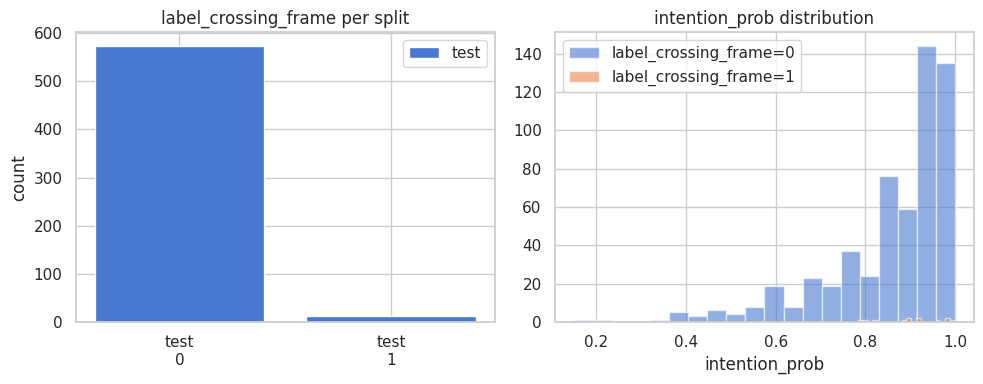

label_crossing_frame: neg=573, pos=12, pos_weight=47.75


In [3]:
label_cols_with_data = [c for c in ['label_crossing', 'label_crossing_frame']
                        if df[c].isin([0, 1]).sum() > 0]

n_panels = len(label_cols_with_data) + 1  # +1 for intention_prob
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
if n_panels == 1:
    axes = [axes]

for ax, label_col in zip(axes, label_cols_with_data):
    for split_name, grp in df.groupby('split'):
        counts = grp[label_col].value_counts().reindex([0, 1], fill_value=0)
        ax.bar([f'{split_name}\n0', f'{split_name}\n1'], counts.values, label=split_name)
    ax.set_title(f'{label_col} per split')
    ax.set_ylabel('count')
    ax.legend()

# intention_prob histogram by primary label
ax_prob = axes[len(label_cols_with_data)]
for label, grp in labeled.groupby(LABEL_COL):
    valid = grp['intention_prob'].dropna()
    valid = valid[valid >= 0]
    ax_prob.hist(valid, bins=20, alpha=0.6, label=f'{LABEL_COL}={int(label)}')
ax_prob.set_title('intention_prob distribution')
ax_prob.set_xlabel('intention_prob')
ax_prob.legend()

plt.tight_layout()
plt.show()

# Class balance summary
for label_col in label_cols_with_data:
    vc = df[label_col].value_counts().sort_index()
    neg, pos = int(vc.get(0, 0)), int(vc.get(1, 0))
    pos_weight = neg / max(pos, 1)
    print(f'{label_col}: neg={neg}, pos={pos}, pos_weight={pos_weight:.2f}')

## 3. Feature Distributions

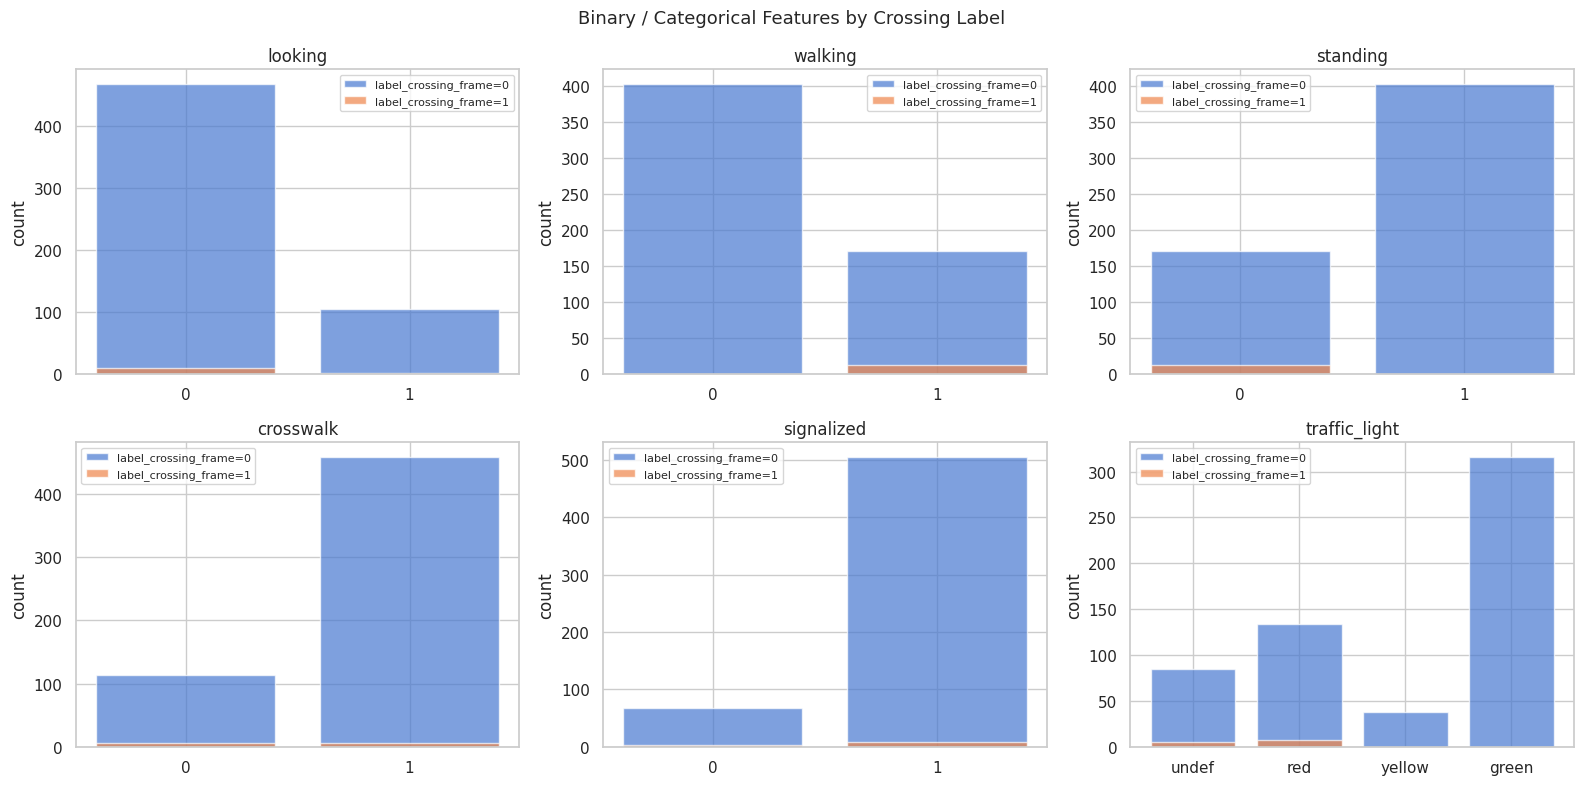

In [4]:
binary_cat_features = ['looking', 'walking', 'standing', 'crosswalk', 'signalized', 'traffic_light']
continuous_features  = ['vehicle_speed_kmh', 'gps_lat', 'gps_lon']
tl_labels = {0: 'undef', 1: 'red', 2: 'yellow', 3: 'green'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, binary_cat_features):
    for label, grp in labeled.groupby(LABEL_COL):
        counts = grp[feat].value_counts().sort_index()
        if feat == 'traffic_light':
            x = [tl_labels.get(int(v), str(v)) for v in counts.index]
        else:
            x = counts.index.astype(str).tolist()
        ax.bar(x, counts.values, alpha=0.7, label=f'{LABEL_COL}={int(label)}')
    ax.set_title(feat)
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.suptitle('Binary / Categorical Features by Crossing Label', fontsize=13)
plt.tight_layout()
plt.show()

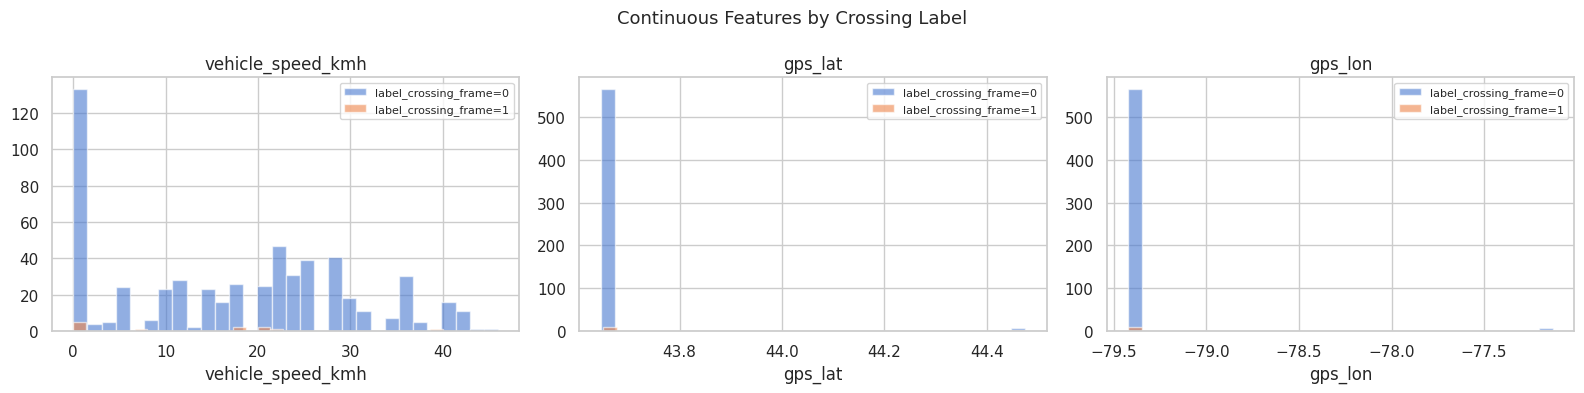

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feat in zip(axes, continuous_features):
    for label, grp in labeled.groupby(LABEL_COL):
        ax.hist(grp[feat].dropna(), bins=30, alpha=0.6, label=f'{LABEL_COL}={int(label)}')
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.suptitle('Continuous Features by Crossing Label', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

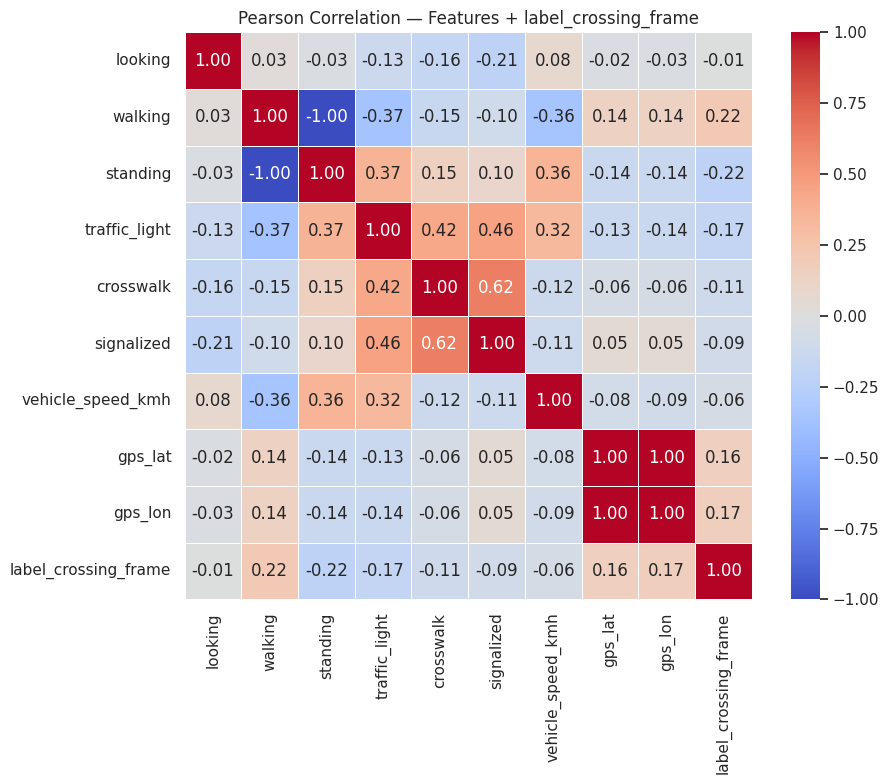

Correlation with label_crossing_frame (absolute):
walking              0.215343
standing             0.215343
traffic_light        0.172437
gps_lon              0.166095
gps_lat              0.162398
crosswalk            0.105678
signalized           0.092618
vehicle_speed_kmh    0.056253
looking              0.006079


In [6]:
corr_cols = FEATURE_KEYS + [LABEL_COL]
corr = labeled[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title(f'Pearson Correlation — Features + {LABEL_COL}')
plt.tight_layout()
plt.show()

label_corr = corr[LABEL_COL].drop(LABEL_COL).abs().sort_values(ascending=False)
print(f'Correlation with {LABEL_COL} (absolute):')
print(label_corr.to_string())

## 5. Feature–Label Relationships

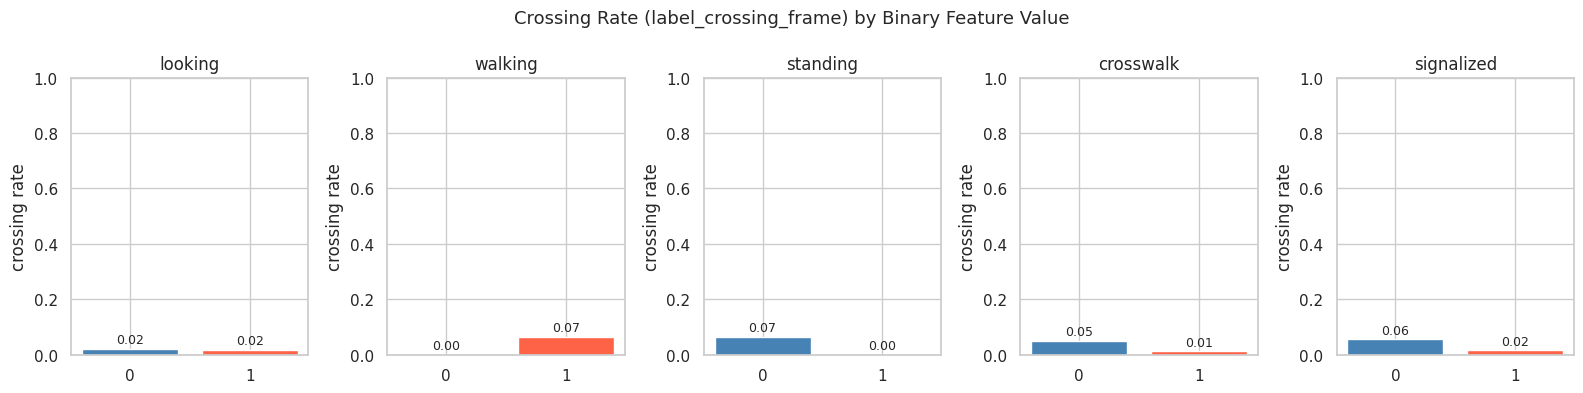

In [7]:
binary_features = ['looking', 'walking', 'standing', 'crosswalk', 'signalized']

rates = {feat: labeled.groupby(feat)[LABEL_COL].mean() for feat in binary_features}

fig, axes = plt.subplots(1, len(binary_features), figsize=(16, 4))
for ax, feat in zip(axes, binary_features):
    r = rates[feat]
    ax.bar(r.index.astype(str), r.values, color=['steelblue', 'tomato'][:len(r)])
    ax.set_title(feat)
    ax.set_ylabel('crossing rate')
    ax.set_ylim(0, 1)
    for i, (x, y) in enumerate(zip(r.index.astype(str), r.values)):
        ax.text(i, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)

plt.suptitle(f'Crossing Rate ({LABEL_COL}) by Binary Feature Value', fontsize=13)
plt.tight_layout()
plt.show()

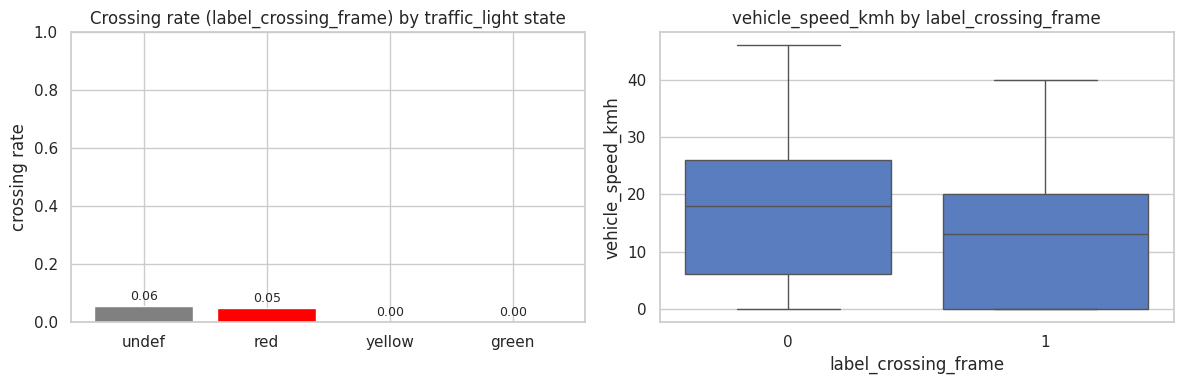

In [8]:
tl_rate = labeled.groupby('traffic_light')[LABEL_COL].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tl_x = [tl_labels.get(int(v), str(v)) for v in tl_rate.index]
axes[0].bar(tl_x, tl_rate.values, color=['grey', 'red', 'gold', 'green'][:len(tl_rate)])
axes[0].set_title(f'Crossing rate ({LABEL_COL}) by traffic_light state')
axes[0].set_ylabel('crossing rate')
axes[0].set_ylim(0, 1)
for i, (x, y) in enumerate(zip(tl_x, tl_rate.values)):
    axes[0].text(i, y + 0.02, f'{y:.2f}', ha='center', fontsize=9)

speed_data = labeled[['vehicle_speed_kmh', LABEL_COL]].dropna()
if not speed_data.empty:
    sns.boxplot(data=speed_data, x=LABEL_COL, y='vehicle_speed_kmh', ax=axes[1])
    axes[1].set_title(f'vehicle_speed_kmh by {LABEL_COL}')
    axes[1].set_xlabel(LABEL_COL)
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('vehicle_speed_kmh (no data)')

plt.tight_layout()
plt.show()

## 6. Data Quality & Metadata

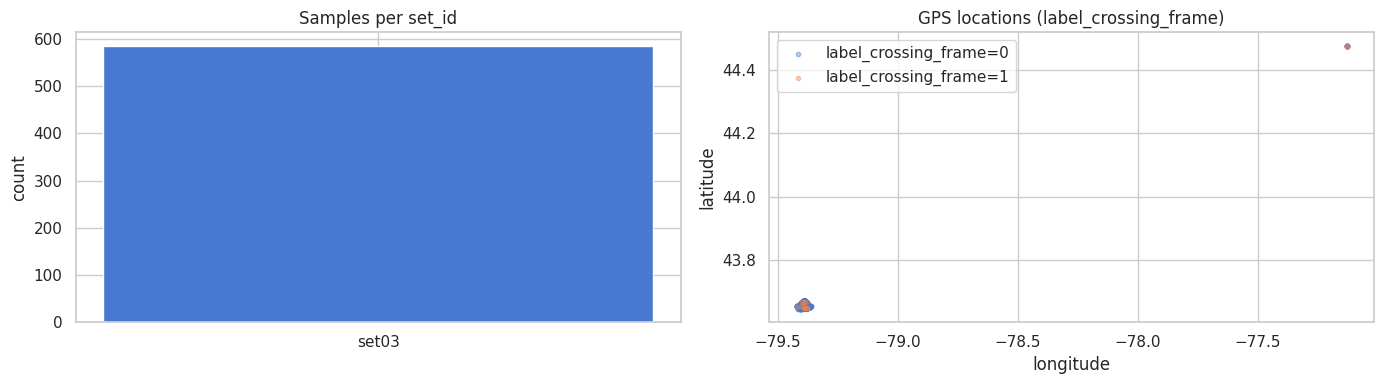


Missing values per feature column:
looking              0
walking              0
standing             0
traffic_light        0
crosswalk            0
signalized           0
vehicle_speed_kmh    0
gps_lat              0
gps_lon              0

Rows with null label_crossing: 585 / 585
Rows with null label_crossing_frame: 0 / 585


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

set_counts = df['set_id'].value_counts().sort_index()
axes[0].bar(set_counts.index, set_counts.values)
axes[0].set_title('Samples per set_id')
axes[0].set_ylabel('count')

for label, grp in labeled.groupby(LABEL_COL):
    axes[1].scatter(grp['gps_lon'], grp['gps_lat'], alpha=0.4, s=10, label=f'{LABEL_COL}={int(label)}')
axes[1].set_title(f'GPS locations ({LABEL_COL})')
axes[1].set_xlabel('longitude')
axes[1].set_ylabel('latitude')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nMissing values per feature column:')
print(df[FEATURE_KEYS].isnull().sum().to_string())
print(f'\nRows with null label_crossing: {df["label_crossing"].isna().sum()} / {len(df)}')
print(f'Rows with null label_crossing_frame: {df["label_crossing_frame"].isna().sum()} / {len(df)}')

## 7. Summary

**Dataset loaded:** test split only (set03, 585 samples, 19 videos). Train/val splits pending feature extraction.

**Class balance:**
- `label_crossing` (track-level intent): all `None` in the test split — labels only available in train/val
- `label_crossing_frame` (frame-level crossing): neg=573, pos=12 → **pos_weight ≈ 47.75** — severe imbalance; use `BCEWithLogitsLoss(pos_weight=...)` during training

**Strongest feature correlations with `label_crossing_frame`:**
- `walking` (+0.22) — pedestrians actively walking are more likely to be crossing at that frame
- `standing` (−0.22) — standing pedestrians are less likely to be crossing (mirror of walking)
- `gps_lon` (+0.17), `gps_lat` (+0.16) — location-dependent; likely reflects specific intersections where crossings occur
- All other features show weak correlation (|r| < 0.2) with the frame-level label

**Notable observations:**
- `walking` and `standing` are perfectly anti-correlated (−1.00) — one is fully redundant; consider dropping `standing`
- `crosswalk` and `signalized` are strongly correlated (+0.62) — signalized crossings are a subset of crosswalks
- `vehicle_speed_kmh` peaks near 0 km/h (many stopped vehicles) with a secondary distribution around 15–30 km/h
- `traffic_light` is mostly `green` (3) with some `undef` (0) and `red` (1); yellow is rare
- GPS points cluster tightly around one intersection (~43.65°N, −79.37°W) with one outlier — likely a data artifact
- No missing values in any feature column

**Recommendations for modelling:**
- Use `pos_weight ≈ 48` in `BCEWithLogitsLoss` to handle class imbalance, or consider oversampling
- Drop `standing` (perfectly collinear with `walking`)
- Consider normalising `vehicle_speed_kmh` and GPS coordinates (zero-mean, unit-variance)
- Treat `traffic_light` as ordinal or one-hot encode it rather than using raw integer values
- Re-run this notebook once train/val features are extracted to get reliable per-split statistics and `label_crossing` distributions